# 01 – Datenexploration: E-Ladesäulen Würzburg
Überblick über den Datensatz, Koordinaten, Betreiber, Leistungsklassen.

In [ ]:
import sys
sys.path.insert(0, '..')  # Projekt-Root

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_config, load_stations, get_coordinates

config = load_config('../configs/config.yaml')
config['data']['raw_path'] = '../data/raw/charging_stations_wue.csv'

df = load_stations(config)
print(f'Stationen geladen: {len(df)}')
df.head()

In [ ]:
print('Spalten:', df.columns.tolist())
print()
df.info()

## Betreiber-Verteilung

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Betreiber'].value_counts().plot(kind='barh', ax=axes[0])
axes[0].set_title('Stationen nach Betreiber')
axes[0].set_xlabel('Anzahl')

df['Nennleistung Ladeeinrichtung [kW]'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1]
)
axes[1].set_title('Nennleistung [kW]')
axes[1].set_xlabel('kW')
plt.tight_layout()
plt.show()

## Karte aller Ladesäulen

In [ ]:
from src.utils.visualization import plot_stations_map

depot = (config['depot']['lat'], config['depot']['lon'])
m = plot_stations_map(df, depot=depot)
m.save('../data/processed/map_all_stations.html')
m

## Koordinaten-Statistik

In [ ]:
lat_col = config['data']['lat_col']
lon_col = config['data']['lon_col']

print('Breitengrad:', df[lat_col].min(), '–', df[lat_col].max())
print('Längengrad: ', df[lon_col].min(), '–', df[lon_col].max())
print('\nAnzahl eindeutiger Koordinaten:', df[[lat_col, lon_col]].drop_duplicates().shape[0])

## Fahrzeit-Matrix (OSRM)

Matrix-Größe: 398×398

Fahrzeit (Minuten):
  Min:    0.0
  Median: 15.2
  Max:    66.8

Distanz (km):
  Min:    -0.00
  Median: 12.63
  Max:    83.66


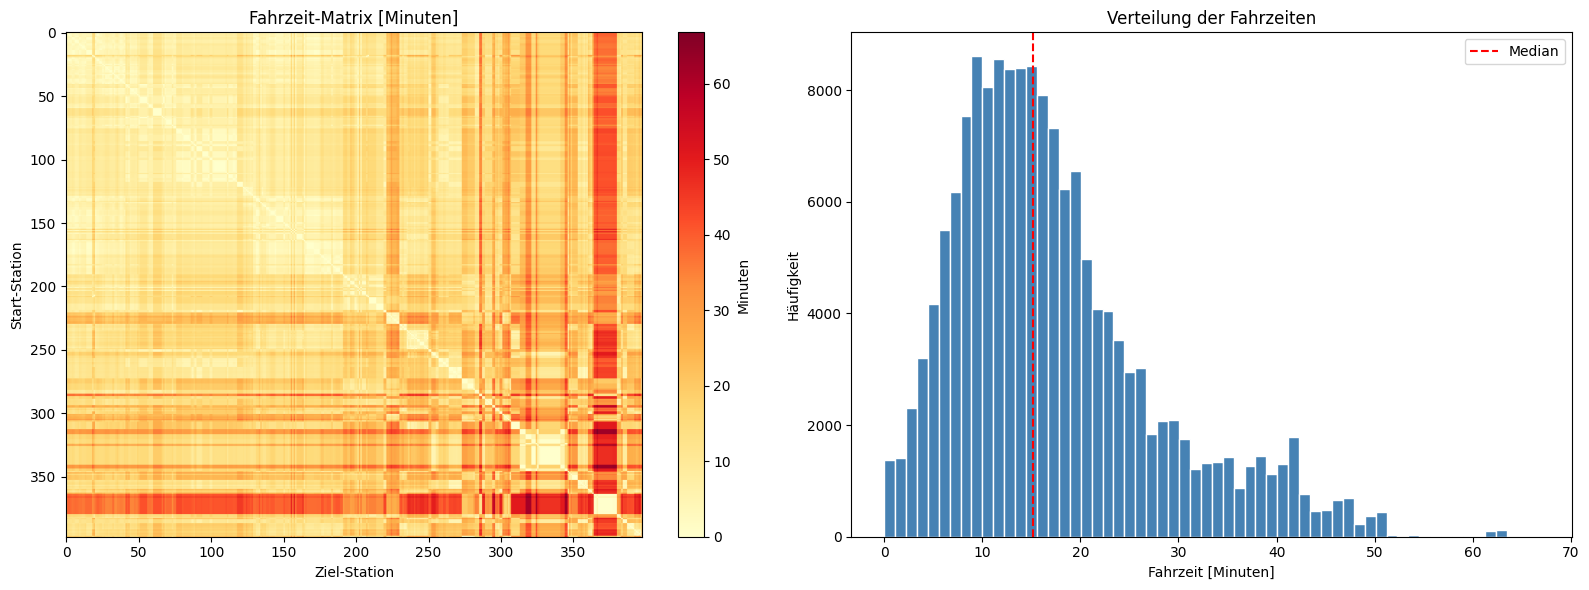

In [2]:
import numpy as np
import matplotlib.pyplot as plt

duration = np.load('../data/distance_matrices/travel_times_duration.npy')
distance = np.load('../data/distance_matrices/travel_times_distance.npy')

n = duration.shape[0]
mask = ~np.eye(n, dtype=bool)  # Diagonale ausblenden

print(f"Matrix-Größe: {n}×{n}")
print(f"\nFahrzeit (Minuten):")
print(f"  Min:    {duration[mask].min()/60:.1f}")
print(f"  Median: {np.median(duration[mask])/60:.1f}")
print(f"  Max:    {duration[mask].max()/60:.1f}")
print(f"\nDistanz (km):")
print(f"  Min:    {distance[mask].min()/1000:.2f}")
print(f"  Median: {np.median(distance[mask])/1000:.2f}")
print(f"  Max:    {distance[mask].max()/1000:.2f}")

# Heatmap der Fahrzeit-Matrix (in Minuten)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(duration / 60, cmap='YlOrRd', aspect='auto')
axes[0].set_title('Fahrzeit-Matrix [Minuten]')
axes[0].set_xlabel('Ziel-Station')
axes[0].set_ylabel('Start-Station')
plt.colorbar(im0, ax=axes[0], label='Minuten')

# Histogramm der Fahrzeiten
axes[1].hist(duration[mask] / 60, bins=60, color='steelblue', edgecolor='white')
axes[1].set_title('Verteilung der Fahrzeiten')
axes[1].set_xlabel('Fahrzeit [Minuten]')
axes[1].set_ylabel('Häufigkeit')
axes[1].axvline(np.median(duration[mask]) / 60, color='red', linestyle='--', label=f'Median')
axes[1].legend()

plt.tight_layout()
plt.show()